# Viable Pareto Energy Management — authoritative companion notebook

**Paper:** *Viable Pareto Energy Management: A Resilience-First Dispatch Policy for
Islanded Microgrids under Renewable Drift.*

This notebook is the **single canonical pipeline** for the manuscript: every figure,
table and reported number is produced here and exported to `results/` as CSV/JSON.
It supersedes `compute.py` and `compute_ext.py`, which are withdrawn.

## Revision log (v2)

Addressing an external methodological review:

| Ref | Issue | Resolution |
|---|---|---|
| C1 | Monte-Carlo not reproducible | Notebook generator is now authoritative; **all** OU parameters are in `Cfg` and stated in the paper |
| C2 | Confidence bound inconsistent | Clopper–Pearson one-sided upper limit, computed once and reused |
| C3 | E5 numbers not reproducible | Regenerated from this notebook; manuscript synced |
| C4 | Simulator was not the stated integrator | Single `step_state`, **exact zero-order-hold** update, used by simulator, MPC and tests |
| C5 | Generator saturation outside the control set | State-dependent admissible set `U(g)`, applied before integration |
| C6 | Refined-kernel areas used the nominal formula | Generic area integral `viable_fraction` for every variant |
| C7 | Discharge-efficiency model inconsistent | $\dot s=(g-d)/\eta$ on discharge, $\dot s=g-d$ on charge |
| C8 | Curtailment conflicted with $d=L_c-r$ | Deficit redefined as $d=L_c+L_{nc}-r$ |
| C9 | Bounded-drought class imprecise | Stated as a finite-horizon survival set, not an infinite-horizon kernel |
| C10 | "Viable Pareto frontier" overclaimed | Renamed; certified subset marked explicitly |
| B1–B2 | MPC baseline too weak | **Genuine finite-horizon MPC** over a decision sequence, plus **MPC + terminal viability constraint** |
| N1–N10 | Config, globals, integrator, tests, exports | `Cfg` object, explicit `p` everywhere, assertions, CSV/JSON export |

## Model

State $x=(s,g)$: battery state of charge (kWh) and ramp-limited dispatchable output
(kW). Control $u=\dot g$. Disturbance $d=L_c+L_{nc}-r$, the net deficit.

$$\dot s = \begin{cases}(g-d)/\eta & g<d \ \text{(discharge)}\\ g-d & g\ge d\end{cases}
\qquad \dot g = u \in U(g).$$

Kernel under worst-case deficit: $V=\{\mu\ge0\}$ with
$\mu(s,g)=s-s_{\min}(g)$, nominally $s_{\min}(g)=(d_{hi}-g)^2/2R$.

In [1]:
import json
import os
from dataclasses import dataclass, replace, asdict, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import beta as beta_dist

rcParams.update({
    "font.size": 10, "font.family": "serif", "axes.grid": True,
    "grid.alpha": 0.25, "figure.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})

FIGDIR, RESDIR = "Figures", "results"
os.makedirs(FIGDIR, exist_ok=True); os.makedirs(RESDIR, exist_ok=True)

C = {"greedy": "#C0504D", "viable": "#2E5496", "prop": "#4E9A51",
     "mpc": "#B07AA1", "mpcv": "#7B4F9D", "reserve": "#E08214", "neutral": "#7F7F7F"}

TOL = 1e-9

## 0.1 Configuration

`Params` holds the plant; `Cfg` holds everything else that defines an experiment.
Both are frozen and exported to `results/parameters.json`, so the paper can quote
them and a referee can regenerate every number. **No experiment reads a global.**

In [2]:
@dataclass(frozen=True)
class Params:
    """Plant parameters. Defaults are the nominal design of the paper."""
    S_max: float = 20.0     # kWh   usable battery capacity
    G_max: float = 6.0      # kW    dispatchable maximum (sizing requires >= d_hi)
    R:     float = 1.5      # kW/h  ramp limit
    d_hi:  float = 5.0      # kW    worst-case net deficit
    d_lo:  float = -3.0     # kW    best case (renewable surplus)
    dt:    float = 0.02     # h     EMS sampling / integration step
    # --- refinements (Prop. 3); defaults recover the nominal model ---
    eta:   float = 1.0      # -     discharge efficiency
    tau:   float = 0.0      # h     generator start-up dead time
    s_dod: float = 0.0      # kWh   unusable floor (depth-of-discharge limit)
    L_nc:  float = 0.0      # kW    curtailable non-critical load included in d
    T_d:   float = np.inf   # h     maximum drought duration (finite-horizon variant)


@dataclass(frozen=True)
class Cfg:
    """Experiment configuration: everything not in the plant."""
    seed: int = 20250901
    # worst-case tube
    T_wc: float = 12.0
    s0: float = 10.0
    g0: float = 1.0
    drought_start: float = 2.5
    drought_end: float = 7.5
    # Monte-Carlo / OU disturbance  (C1: these are now stated in the paper)
    n_mc: int = 300
    T_mc: float = 24.0
    ou_theta: float = 1.2        # mean-reversion rate [1/h]
    ou_sigma: float = 1.1        # volatility [kW/sqrt(h)]
    ou_mean_offset: float = 1.0  # kW, seasonal mean level
    ou_mean_amp: float = 1.5     # kW, seasonal amplitude
    ou_period: float = 24.0      # h
    n_plateau: tuple = (1, 2)    # inclusive range of drought plateaus per scenario
    plateau_dur: tuple = (2.0, 6.0)   # h
    # policies
    mu_bar_bb: float = 0.5
    mu_bar_prop: float = 1.0
    kp_prop: float = 3.0
    # MPC
    mpc_block: float = 0.5       # h, decision block length
    mpc_nu: int = 5              # ramp levels per block
    mpc_ns: int = 61             # DP grid in s
    mpc_ng: int = 31             # DP grid in g
    mpc_shed_penalty: float = 1e3
    # affine genset cost
    c_marginal: float = 1.0
    c_noload: float = 0.6        # kW-equivalent while running
    c_start: float = 2.0         # kWh-equivalent per start


P, CFG = Params(), Cfg()
assert P.G_max >= P.d_hi, "V is empty unless G_max >= d_hi (Prop. 1, remark 2)"

with open(f"{RESDIR}/parameters.json", "w") as f:
    json.dump({"params": asdict(P), "cfg": {k: list(v) if isinstance(v, tuple) else v
                                            for k, v in asdict(CFG).items()}},
              f, indent=2, default=str)
print(json.dumps({"params": asdict(P)}, indent=2, default=str))

{
  "params": {
    "S_max": 20.0,
    "G_max": 6.0,
    "R": 1.5,
    "d_hi": 5.0,
    "d_lo": -3.0,
    "dt": 0.02,
    "eta": 1.0,
    "tau": 0.0,
    "s_dod": 0.0,
    "L_nc": 0.0,
    "T_d": Infinity
  }
}


## 0.2 Kernel geometry

`s_min` is the general Proposition 3 boundary; the defaults collapse it to
$(d_{hi}-g)^2/2R$. **C6:** the viable fraction is now a genuine area integral of
*this* boundary, so every refinement gets its own value; the nominal closed form
`viable_fraction_closed_form` is reported separately and only where it is valid.

In [3]:
def s_min(g, p: Params):
    """Minimal viable reserve at dispatch g (Prop. 1 nominally, Prop. 3 in general).

    delta        deficit the actuator must still cover
    dead         energy drawn during the start-up dead time tau      (Prop. 3c)
    ramp         energy drawn while ramping, truncated at T_d        (Prop. 3d)
    /eta         discharge losses                                     (Prop. 3a)
    + s_dod      unusable floor                                       (Prop. 3b)
    L_nc         curtailable load removed from the deficit            (Prop. 3e)
    """
    g = np.asarray(g, dtype=float)
    delta = np.maximum(p.d_hi - p.L_nc - g, 0.0)
    t_end = np.minimum(p.T_d, delta / p.R)
    ramp = delta * t_end - 0.5 * p.R * t_end**2
    return p.s_dod + (p.tau * delta + ramp) / p.eta


def margin(s, g, p: Params):
    """Viability margin. V = {mu >= 0}; mu is a control barrier certificate for V."""
    return s - s_min(g, p)


def viable_fraction(p: Params, n=200001):
    """|V|/|K| by direct integration of the actual boundary (C6).

    Valid for every refinement, and handles truncation by S_max.
    """
    g = np.linspace(0, p.G_max, n)
    nonviable = np.trapezoid(np.clip(s_min(g, p), 0, p.S_max), g)
    return 1 - nonviable / (p.S_max * p.G_max)


def viable_fraction_closed_form(p: Params):
    """Nominal closed form (Eq. 11) and whether its validity condition holds.

    Only meaningful for the nominal model: eta=1, tau=0, s_dod=0, L_nc=0, T_d=inf.
    """
    nominal = (p.eta == 1 and p.tau == 0 and p.s_dod == 0
               and p.L_nc == 0 and np.isinf(p.T_d))
    valid = nominal and p.R >= p.d_hi**2 / (2 * p.S_max)
    return 1 - p.d_hi**3 / (6 * p.R * p.S_max * p.G_max), valid


frac_cf, cf_valid = viable_fraction_closed_form(P)
frac = viable_fraction(P)
print(f"viable fraction: integral {frac:.4f}   closed form {frac_cf:.4f} "
      f"(valid: {cf_valid})")
print(f"validity condition R >= d_hi^2/(2 S_max) = {P.d_hi**2/(2*P.S_max):.3f} kW/h"
      f"   [nominal R = {P.R}]")
print(f"s_min(0) = {s_min(0.0, P):.3f} kWh ({100*s_min(0.0,P)/P.S_max:.0f}% of battery)")
assert abs(frac - frac_cf) < 1e-4, "integral and closed form must agree nominally"

viable fraction: integral 0.8843   closed form 0.8843 (valid: True)
validity condition R >= d_hi^2/(2 S_max) = 0.625 kW/h   [nominal R = 1.5]
s_min(0) = 8.333 kWh (42% of battery)


## 0.3 Admissible controls and the one integrator

**C5 — state-dependent control set.** The model imposes $0\le g\le G_{\max}$, so the
admissible ramp at the boundaries is one-sided:

$$U(g)=\begin{cases}[0,R] & g=0\\ [-R,R] & 0<g<G_{\max}\\ [-R,0] & g=G_{\max}.\end{cases}$$

This is applied *before* integration rather than by clipping the state afterwards,
so simulator and theory use the same convention.

**C4 — exact zero-order hold.** With $u$ held constant over $[t_k,t_k+\Delta t)$ and
$d$ piecewise constant, the continuous dynamics integrate *exactly* to

$$g_{k+1}=g_k+u_k\Delta t, \qquad
s_{k+1}=s_k+(g_k-d_k)\Delta t+\tfrac12 u_k\Delta t^2,$$

(the storage term divided by $\eta$ while discharging). This replaces the earlier
update, which used the *new* $g$ and was therefore neither explicit Euler nor exact.
`step_state` is the only integrator in the notebook: the simulator, the MPC
predictor and the tests all call it.

In [4]:
def admissible_u(u, g, p: Params):
    """Project a requested ramp onto U(g) (C5)."""
    lo = -p.R if g > TOL else 0.0
    hi = +p.R if g < p.G_max - TOL else 0.0
    return float(np.clip(u, lo, hi))


def step_state(s, g, u, d, p: Params):
    """One exact zero-order-hold step. Returns (s', g', u_eff, shed_kWh).

    u is projected onto U(g) first; if the ramp would still cross a generator bound
    within the step, u_eff is the average realised ramp, which keeps the quadratic
    term consistent with the trajectory actually followed.
    """
    u = admissible_u(u, g, p)
    g_new = min(max(g + u * p.dt, 0.0), p.G_max)
    u_eff = (g_new - g) / p.dt

    de = (g - d) * p.dt + 0.5 * u_eff * p.dt**2      # exact ZOH energy increment
    if de < 0.0:
        de /= p.eta                                   # discharge losses only (C7)
    s_new = s + de

    shed = 0.0
    if s_new < p.s_dod:
        shed = p.s_dod - s_new                        # unserved critical energy [kWh]
        s_new = p.s_dod
    s_new = min(s_new, p.S_max)                       # surplus is curtailed
    return s_new, g_new, u_eff, shed


def simulate(policy, d_series, p: Params, cfg: Cfg = CFG, s0=None, g0=None, record=False):
    """Roll the plant forward. policy(s, g, d, k, d_series, p) -> requested ramp."""
    s = cfg.s0 if s0 is None else s0
    g = cfg.g0 if g0 is None else g0
    fuel = shed = on_time = 0.0
    starts = 0
    prev_on = g > TOL
    hist = {k: [] for k in ("s", "g", "mu", "shed_kW")}

    for k, d in enumerate(d_series):
        u = policy(s, g, d, k, d_series, p)
        s, g, _, sh = step_state(s, g, u, d, p)
        shed += sh
        fuel += g * p.dt
        on = g > TOL
        on_time += p.dt if on else 0.0
        starts += int(on and not prev_on)
        prev_on = on
        if record:
            hist["s"].append(s); hist["g"].append(g)
            hist["mu"].append(margin(s, g, p)); hist["shed_kW"].append(sh / p.dt)

    out = dict(fuel=fuel, shed=shed, on_time=on_time, starts=starts)
    if record:
        out |= {k: np.array(v) for k, v in hist.items()}
        out["min_mu"] = out["mu"].min()
    return out


def affine_cost(r, cfg: Cfg = CFG):
    """Dispatchable operating cost beyond raw energy (M5): marginal + no-load + starts."""
    return (cfg.c_marginal * r["fuel"] + cfg.c_noload * r["on_time"]
            + cfg.c_start * r["starts"])

## 0.4 Disturbance paths

**C8 — deficit definition.** $d=L_c+L_{nc}-r$: the deficit contains both the
protected critical load and the curtailable non-critical load, so curtailing $L_{nc}$
genuinely reduces the deficit the actuator must chase. (In the earlier formulation
$d=L_c-r$ contained only critical load, and Prop. 3e was inconsistent with it.)

Every OU parameter is in `Cfg` and stated in the paper (C1).

In [5]:
def worst_case_series(p: Params, cfg: Cfg = CFG):
    """Bounded tube: surplus, one-hour ramp-in, five-hour drought at d_hi, recovery."""
    t = np.arange(0, cfg.T_wc, p.dt)
    d = np.full_like(t, p.d_lo)
    a, b = cfg.drought_start, cfg.drought_end
    up = (t >= a - 1.0) & (t < a)
    d[up] = p.d_lo + (p.d_hi - p.d_lo) * (t[up] - (a - 1.0))
    d[(t >= a) & (t < b)] = p.d_hi
    dn = (t >= b) & (t < b + 1.0)
    d[dn] = p.d_hi - (p.d_hi - p.d_lo) * (t[dn] - b)
    return t, np.clip(d, p.d_lo, p.d_hi)


def ou_series(rng, p: Params, cfg: Cfg = CFG):
    """Clipped Ornstein-Uhlenbeck deficit about a slow seasonal mean, plus droughts.

        dd = theta (m(t) - d) dt + sigma dW,
        m(t) = ou_mean_offset + ou_mean_amp * sin(2 pi t / ou_period),

    then 1-2 plateaus of 2-6 h clamped to d_hi, finally clipped to [d_lo, d_hi].
    """
    n = int(cfg.T_mc / p.dt)
    t = np.arange(n) * p.dt
    m = cfg.ou_mean_offset + cfg.ou_mean_amp * np.sin(2 * np.pi * t / cfg.ou_period)
    d = np.empty(n); d[0] = m[0]
    for k in range(1, n):
        d[k] = (d[k-1] + cfg.ou_theta * (m[k] - d[k-1]) * p.dt
                + cfg.ou_sigma * np.sqrt(p.dt) * rng.normal())
    for _ in range(rng.integers(cfg.n_plateau[0], cfg.n_plateau[1] + 1)):
        dur = rng.uniform(*cfg.plateau_dur)
        t0 = rng.uniform(0, cfg.T_mc - dur)
        d[(t >= t0) & (t < t0 + dur)] = p.d_hi
    return np.clip(d, p.d_lo, p.d_hi)

## 0.5 Policies

Signature `(s, g, d, k, d_series, p) -> u`. **N2:** every policy takes `p`
explicitly; none reads a global. Only the predictive controllers look ahead in
`d_series` — the viable rules and the fixed reserve are forecast-free.

In [6]:
def greedy(s, g, d, k, ds, p):
    """Efficiency-greedy (Pareto-only): always ramp down."""
    return -p.R


def viable_bangbang(mu_bar):
    """Eq. (13). Minimal tangency-compatible viable feedback."""
    def pol(s, g, d, k, ds, p):
        return +p.R if margin(s, g, p) <= mu_bar else -p.R
    return pol


def viable_proportional(mu_bar, kp=CFG.kp_prop):
    """Eq. (14). Regulates the margin to a positive setpoint; stays interior to V."""
    def pol(s, g, d, k, ds, p):
        return kp * (mu_bar - margin(s, g, p))
    return pol


def fixed_reserve(s_res):
    """State-of-practice: a CONSTANT energy reserve, blind to the actuator state."""
    def pol(s, g, d, k, ds, p):
        return +p.R if s <= s_res else -p.R
    return pol

## 0.6 Finite-horizon economic MPC (B1)

The earlier baseline chose a *single* constant ramp for the whole horizon, which is
a heuristic rather than an MPC. This is a genuine finite-horizon controller:

* the decision variable is a **sequence** $u_1,\dots,u_{N}$ of ramps, one per
  decision block of length `mpc_block`;
* the horizon problem is solved to optimality **by backward dynamic programming**
  on a discretised $(s,g)$ grid, so the whole sequence is optimised jointly;
* the objective is dispatchable energy plus a large penalty on unserved critical
  energy, subject to the true plant bounds, integrated with the *same* `step_state`;
* it is re-solved in receding fashion at every block boundary.

`terminal_viability=True` adds the closed-form kernel as a **terminal constraint**
(B2) — the experiment the paper's future-work section proposed:

$$s_{k+N}\ \ge\ s_{\min}(g_{k+N}).$$

Because the kernel is closed form, this costs one comparison per terminal grid node.

In [7]:
def _block_transition(p: Params, cfg: Cfg, d_block, s_grid, g_grid, u_levels):
    """Simulate one decision block from every grid node under every ramp level.

    Returns (s_next, g_next, stage_cost) each of shape (ns, ng, nu), using step_state
    so the MPC predictor and the plant share one integrator (N3).
    """
    ns, ng, nu = len(s_grid), len(g_grid), len(u_levels)
    S = np.repeat(s_grid[:, None, None], ng, 1).repeat(nu, 2).astype(float)
    G = np.repeat(g_grid[None, :, None], ns, 0).repeat(nu, 2).astype(float)
    U = np.repeat(u_levels[None, None, :], ns, 0).repeat(ng, 1).astype(float)
    cost = np.zeros_like(S)

    for d in d_block:
        u = np.clip(U, np.where(G > TOL, -p.R, 0.0), np.where(G < p.G_max - TOL, p.R, 0.0))
        G_new = np.clip(G + u * p.dt, 0.0, p.G_max)
        u_eff = (G_new - G) / p.dt
        de = (G - d) * p.dt + 0.5 * u_eff * p.dt**2
        de = np.where(de < 0, de / p.eta, de)
        S_new = S + de
        shed = np.maximum(p.s_dod - S_new, 0.0)
        S_new = np.minimum(np.maximum(S_new, p.s_dod), p.S_max)
        cost += G_new * p.dt + cfg.mpc_shed_penalty * shed
        S, G = S_new, G_new
    return S, G, cost


def _interp_cost(J, s_grid, g_grid, S, G):
    """Bilinear interpolation of the cost-to-go J at arbitrary (S, G)."""
    ds = s_grid[1] - s_grid[0]; dg = g_grid[1] - g_grid[0]
    a = np.clip((S - s_grid[0]) / ds, 0, len(s_grid) - 1.001)
    b = np.clip((G - g_grid[0]) / dg, 0, len(g_grid) - 1.001)
    i0 = a.astype(int); j0 = b.astype(int)
    fa = a - i0; fb = b - j0
    return ((1-fa)*(1-fb)*J[i0, j0] + (1-fa)*fb*J[i0, j0+1]
            + fa*(1-fb)*J[i0+1, j0] + fa*fb*J[i0+1, j0+1])


def mpc_policy(H, forecast_bias=0.0, terminal_viability=False, cfg: Cfg = CFG):
    """Receding-horizon economic MPC; see the markdown above."""
    state = {"t_next": -1.0, "plan": None}

    def solve(s, g, k, ds, p):
        nb = max(1, int(round(H / cfg.mpc_block)))
        per = max(1, int(round(cfg.mpc_block / p.dt)))
        s_grid = np.linspace(p.s_dod, p.S_max, cfg.mpc_ns)
        g_grid = np.linspace(0.0, p.G_max, cfg.mpc_ng)
        u_lv = np.linspace(-p.R, p.R, cfg.mpc_nu)

        blocks = []
        for b in range(nb):
            seg = ds[k + b*per: k + (b+1)*per]
            if len(seg) == 0:
                seg = np.full(per, ds[-1])
            elif len(seg) < per:
                seg = np.concatenate([seg, np.full(per - len(seg), seg[-1])])
            if forecast_bias:
                seg = np.clip(seg * (1 - forecast_bias), p.d_lo, p.d_hi)
            blocks.append(seg)

        trans = [_block_transition(p, cfg, blk, s_grid, g_grid, u_lv) for blk in blocks]

        # terminal cost: 0, or +inf outside the kernel when the constraint is on (B2)
        SS, GG = np.meshgrid(s_grid, g_grid, indexing="ij")
        J = np.zeros((cfg.mpc_ns, cfg.mpc_ng))
        if terminal_viability:
            J = np.where(margin(SS, GG, p) >= 0, 0.0, 1e9)

        # backward DP over the decision sequence
        policies = []
        for b in range(nb - 1, -1, -1):
            S_n, G_n, cost = trans[b]
            Q = cost + _interp_cost(J, s_grid, g_grid, S_n, G_n)
            policies.insert(0, u_lv[np.argmin(Q, axis=2)])
            J = Q.min(axis=2)

        ds_ = s_grid[1] - s_grid[0]; dg_ = g_grid[1] - g_grid[0]
        i = int(np.clip(round((s - s_grid[0]) / ds_), 0, cfg.mpc_ns - 1))
        j = int(np.clip(round((g - g_grid[0]) / dg_), 0, cfg.mpc_ng - 1))
        return float(policies[0][i, j])

    def pol(s, g, d, k, ds, p):
        t = k * p.dt
        if t >= state["t_next"] - 1e-12:          # re-solve at each block boundary
            state["plan"] = solve(s, g, k, ds, p)
            state["t_next"] = t + cfg.mpc_block
        return state["plan"]

    pol.reset = lambda: state.update(t_next=-1.0, plan=None)
    return pol


def run_mpc(pol, d_series, p, **kw):
    """MPC objects hold receding-horizon state; reset before each run."""
    pol.reset()
    return simulate(pol, d_series, p, **kw)

## E0 — Viability kernel: closed form and grid verification

**M4:** this is a *numerical consistency check* against the closed form, not an
empirical convergence proof. The analytic result (Prop. 1) is the validation; the
grid computation is supportive. Two competing biases act: nearest-grid membership
gifts up to $\rho/2$ of energy per step (inflating $V$), while the discrete step
deflates it. Their ratio is set by $\rho/h$, so both shrink only if $h$ is refined
more slowly than $\rho$.

[E0] grid fraction 0.890  vs closed form 0.8843


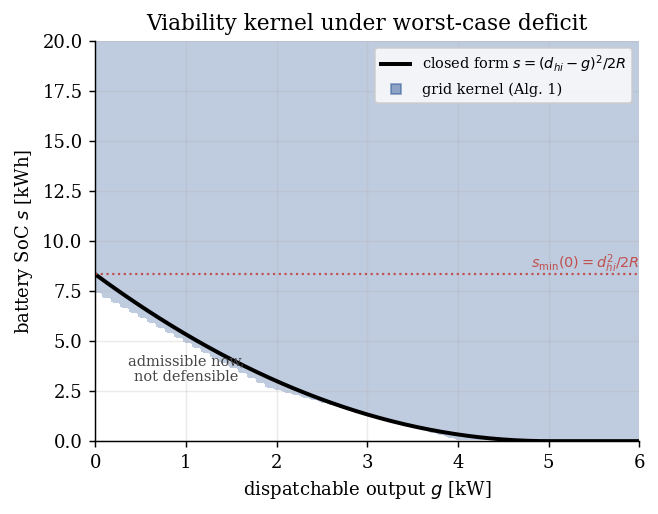

In [8]:
def discrete_kernel(Ns, Ng, h, p: Params, n_u=9):
    """Saint-Pierre-type discrete elimination under the worst-case deficit d = d_hi."""
    ds, dg = p.S_max / (Ns - 1), p.G_max / (Ng - 1)
    S, G = np.meshgrid(np.linspace(0, p.S_max, Ns),
                       np.linspace(0, p.G_max, Ng), indexing="ij")
    SN = S + (G - p.d_hi) * h
    moves = []
    for u in np.linspace(-p.R, p.R, n_u):
        GN = G + u * h
        inbox = (SN >= 0) & (SN <= p.S_max) & (GN >= 0) & (GN <= p.G_max)
        i = np.clip(np.rint(SN / ds).astype(int), 0, Ns - 1)
        j = np.clip(np.rint(GN / dg).astype(int), 0, Ng - 1)
        moves.append((i, j, inbox))
    V = np.ones((Ns, Ng), bool)
    for _ in range(5000):
        keep = np.zeros_like(V)
        for i, j, inbox in moves:
            keep |= inbox & V[i, j]
        new = V & keep
        if new.sum() == V.sum():
            return new
        V = new
    return V


Ns0, Ng0, h0 = 161, 121, 0.06
V0 = discrete_kernel(Ns0, Ng0, h0, P)
print(f"[E0] grid fraction {V0.mean():.3f}  vs closed form {frac:.4f}")

g_line = np.linspace(0, P.G_max, 400)
fig, ax = plt.subplots(figsize=(5.4, 4.0))
ax.contourf(*np.meshgrid(np.linspace(0, P.G_max, Ng0), np.linspace(0, P.S_max, Ns0)),
            V0.astype(float), levels=[0.5, 1.5], colors=[C["viable"]], alpha=0.30)
ax.plot(g_line, s_min(g_line, P), "k-", lw=2.2, label=r"closed form $s=(d_{hi}-g)^2/2R$")
ax.plot([], [], "s", color=C["viable"], alpha=0.5, label="grid kernel (Alg. 1)")
ax.axhline(s_min(0.0, P), color=C["greedy"], ls=":", lw=1.2)
ax.text(P.G_max, s_min(0.0, P) + 0.3, r"$s_{\min}(0)=d_{hi}^2/2R$", fontsize=8,
        ha="right", color=C["greedy"])
ax.annotate("admissible now,\nnot defensible", xy=(1.0, 3.0), fontsize=8,
            ha="center", color="#444444")
ax.set_xlabel(r"dispatchable output $g$ [kW]"); ax.set_ylabel(r"battery SoC $s$ [kWh]")
ax.set_title("Viability kernel under worst-case deficit")
ax.set_xlim(0, P.G_max); ax.set_ylim(0, P.S_max); ax.legend(loc="upper right", fontsize=8)
fig.savefig(f"{FIGDIR}/fig_kernel.pdf"); plt.show()

h ~ rho
    grid     rho       h  fraction   error
   81x61  0.2500  0.0500    0.9168  0.0326
 161x121  0.1250  0.0250    0.9258  0.0415
 321x241  0.0625  0.0125    0.9303  0.0461
 641x481  0.0312  0.0063    0.9326  0.0483
1281x961  0.0156  0.0031    0.9337  0.0495 

h = sqrt(rho/d_hi)
    grid     rho       h  fraction   error
   81x61  0.2500  0.2236    0.8456 -0.0387
 161x121  0.1250  0.1581    0.8746 -0.0096
 321x241  0.0625  0.1118    0.8793 -0.0049
 641x481  0.0312  0.0791    0.8713 -0.0129
1281x961  0.0156  0.0559    0.8759 -0.0084 



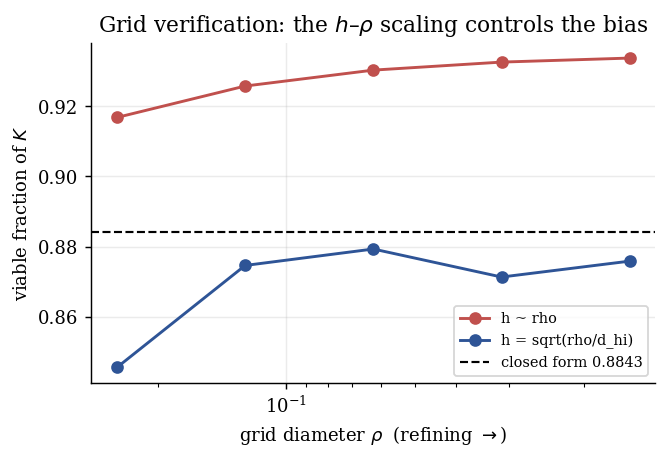

In [9]:
GRIDS = [(81, 61), (161, 121), (321, 241), (641, 481), (1281, 961)]
rows = []
for Ns_, Ng_ in GRIDS:
    rho = max(P.S_max / (Ns_ - 1), P.G_max / (Ng_ - 1))
    for lab, h in (("h ~ rho", rho / P.d_hi), ("h = sqrt(rho/d_hi)", np.sqrt(rho / P.d_hi))):
        f = discrete_kernel(Ns_, Ng_, h, P).mean()
        rows.append(dict(grid=f"{Ns_}x{Ng_}", rho=rho, scaling=lab, h=h,
                         fraction=f, error=f - frac))
conv = pd.DataFrame(rows)
conv.to_csv(f"{RESDIR}/table_kernel_convergence.csv", index=False)
for lab, sub in conv.groupby("scaling", sort=False):
    print(lab); print(sub[["grid", "rho", "h", "fraction", "error"]]
                      .to_string(index=False, float_format=lambda v: f"{v: .4f}"), "\n")

fig, ax = plt.subplots(figsize=(5.6, 3.4))
for (lab, sub), col in zip(conv.groupby("scaling", sort=False), [C["greedy"], C["viable"]]):
    ax.semilogx(sub["rho"], sub["fraction"], "o-", color=col, label=lab, lw=1.6)
ax.axhline(frac, color="k", ls="--", lw=1.2, label=f"closed form {frac:.4f}")
ax.invert_xaxis()
ax.set_xlabel(r"grid diameter $\rho$  (refining $\rightarrow$)")
ax.set_ylabel("viable fraction of $K$")
ax.set_title("Grid verification: the $h$–$\\rho$ scaling controls the bias")
ax.legend(fontsize=8)
fig.savefig(f"{FIGDIR}/fig_convergence.pdf"); plt.show()

## E1 — Design sensitivity

$s_{\min}(0)=d_{hi}^2/2R$: quadratic in the worst deficit, inverse in the ramp rate.
Storage and ramp capability are substitutable resilience resources at the rate
$\partial s_{\min}/\partial R=-d_{hi}^2/2R^2$.

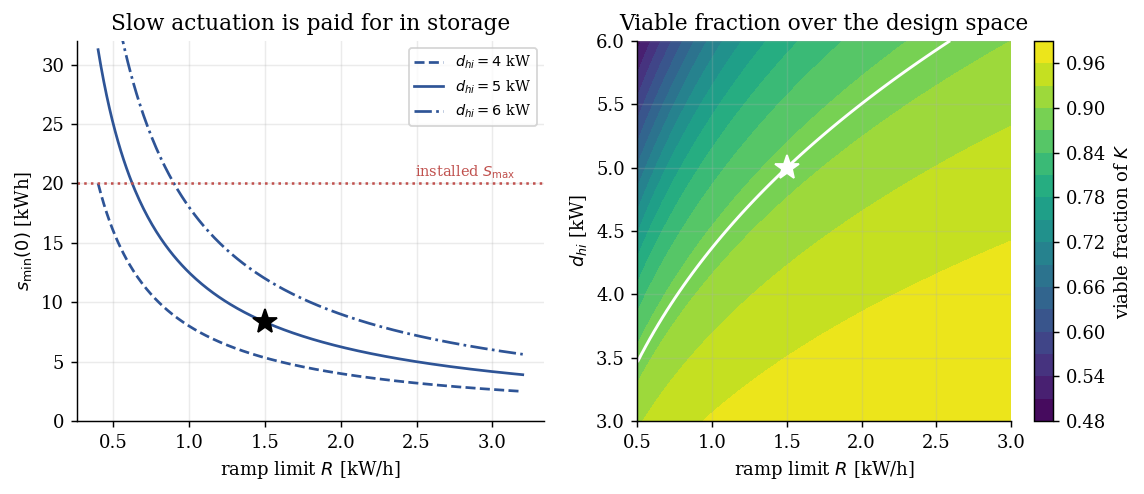

    R  s_min(0)  viable fraction  closed form valid
0.500    25.000            0.664              False
1.000    12.500            0.826               True
1.500     8.333            0.884               True
2.000     6.250            0.913               True
3.000     4.167            0.942               True


In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10.2, 3.8))
R_grid = np.linspace(0.4, 3.2, 300)
for dhi, ls in zip((4.0, 5.0, 6.0), ("--", "-", "-.")):
    axs[0].plot(R_grid, dhi**2 / (2 * R_grid), ls, color=C["viable"],
                label=fr"$d_{{hi}}={dhi:.0f}$ kW")
axs[0].axhline(P.S_max, color=C["greedy"], ls=":", lw=1.4)
axs[0].text(3.15, P.S_max + 0.6, r"installed $S_{\max}$", ha="right", fontsize=8,
            color=C["greedy"])
axs[0].plot([P.R], [s_min(0.0, P)], "*", ms=14, color="k", zorder=5)
axs[0].set_ylim(0, 32); axs[0].set_xlabel(r"ramp limit $R$ [kW/h]")
axs[0].set_ylabel(r"$s_{\min}(0)$ [kWh]"); axs[0].legend(fontsize=8)
axs[0].set_title("Slow actuation is paid for in storage")

Rs, Ds = np.linspace(0.5, 3.0, 90), np.linspace(3.0, 6.0, 90)
RR, DD = np.meshgrid(Rs, Ds)
FR = np.array([[viable_fraction(replace(P, R=r_, d_hi=d_), n=4001)
                for r_ in Rs] for d_ in Ds])
im = axs[1].contourf(RR, DD, FR, levels=18, cmap="viridis")
axs[1].contour(RR, DD, FR, levels=[frac], colors="w", linewidths=1.6)
axs[1].plot([P.R], [P.d_hi], "*", ms=14, color="w")
fig.colorbar(im, ax=axs[1], label="viable fraction of $K$")
axs[1].set_xlabel(r"ramp limit $R$ [kW/h]"); axs[1].set_ylabel(r"$d_{hi}$ [kW]")
axs[1].set_title("Viable fraction over the design space")
fig.savefig(f"{FIGDIR}/fig_sensitivity.pdf"); plt.show()

sens = pd.DataFrame([{"R": r_, "s_min(0)": P.d_hi**2/(2*r_),
                      "viable fraction": viable_fraction(replace(P, R=r_)),
                      "closed form valid": viable_fraction_closed_form(replace(P, R=r_))[1]}
                     for r_ in (0.5, 1.0, 1.5, 2.0, 3.0)])
sens.to_csv(f"{RESDIR}/table_sensitivity.csv", index=False)
print(sens.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

## E2 — Worst-case drought

**R4:** Fig. 4 now uses one of the two formal policies of the methodology
(the bang-bang trigger, Eq. 13). The ad-hoc three-level rule of the withdrawn
`compute.py` is gone — there is a single canonical pipeline.

              policy  dispatchable energy (kWh)  unserved critical (kWh)  starts  min margin (kWh)  affine cost
   Efficiency-greedy                       0.32                    12.70       0             -8.33         0.72
Fixed reserve 10 kWh                      33.09                     0.00       1              1.62        40.73
    Viable bang-bang                      20.88                     0.00       1              0.48        27.73
 Viable proportional                      25.16                     0.00       1              0.50        32.50


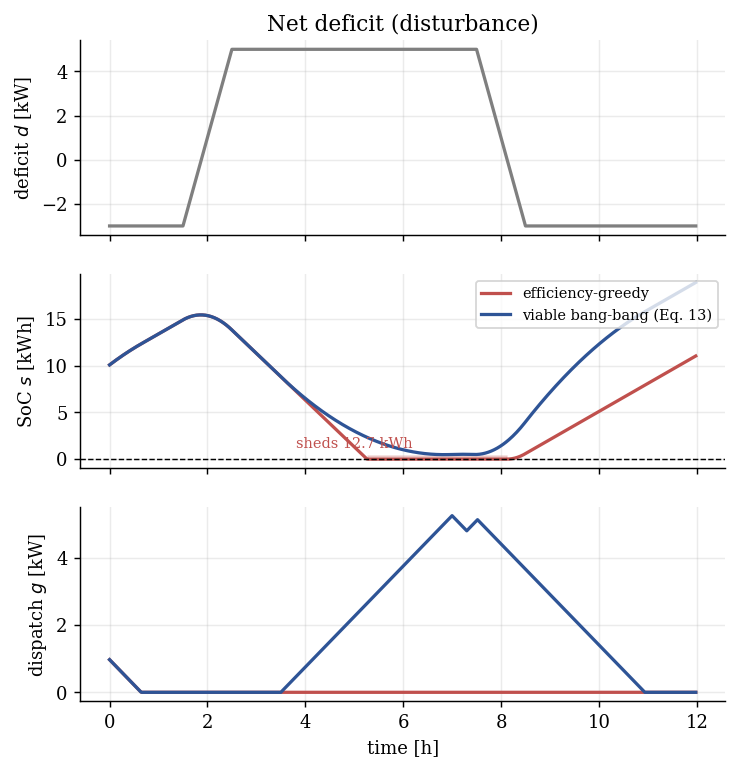

In [11]:
t_wc, d_wc = worst_case_series(P)
runs = {
    "Efficiency-greedy": simulate(greedy, d_wc, P, record=True),
    "Fixed reserve 10 kWh": simulate(fixed_reserve(10.0), d_wc, P, record=True),
    "Viable bang-bang": simulate(viable_bangbang(CFG.mu_bar_bb), d_wc, P, record=True),
    "Viable proportional": simulate(viable_proportional(CFG.mu_bar_prop), d_wc, P, record=True),
}
e2 = pd.DataFrame([{"policy": k, "dispatchable energy (kWh)": r["fuel"],
                    "unserved critical (kWh)": r["shed"], "starts": r["starts"],
                    "min margin (kWh)": r["min_mu"],
                    "affine cost": affine_cost(r)} for k, r in runs.items()])
e2.to_csv(f"{RESDIR}/table_worst_case.csv", index=False)
print(e2.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

fig, axs = plt.subplots(3, 1, figsize=(6.4, 6.6), sharex=True)
axs[0].plot(t_wc, d_wc, color=C["neutral"], lw=1.8)
axs[0].set_ylabel("deficit $d$ [kW]"); axs[0].set_title("Net deficit (disturbance)")
rg, rv = runs["Efficiency-greedy"], runs["Viable bang-bang"]
axs[1].plot(t_wc, rg["s"], color=C["greedy"], lw=1.8, label="efficiency-greedy")
axs[1].plot(t_wc, rv["s"], color=C["viable"], lw=1.8, label="viable bang-bang (Eq. 13)")
axs[1].fill_between(t_wc, 0, np.maximum(rg["s"], 0.35), where=(rg["shed_kW"] > 1e-6),
                    color=C["greedy"], alpha=0.18)
axs[1].annotate(f"sheds {rg['shed']:.1f} kWh", xy=(5.0, 1.2), fontsize=8,
                color=C["greedy"], ha="center")
axs[1].axhline(0, color="k", lw=0.8, ls="--")
axs[1].set_ylabel("SoC $s$ [kWh]"); axs[1].legend(fontsize=8, loc="upper right")
axs[2].plot(t_wc, rg["g"], color=C["greedy"], lw=1.8)
axs[2].plot(t_wc, rv["g"], color=C["viable"], lw=1.8)
axs[2].set_ylabel("dispatch $g$ [kW]"); axs[2].set_xlabel("time [h]")
fig.savefig(f"{FIGDIR}/fig_sim.pdf"); plt.show()

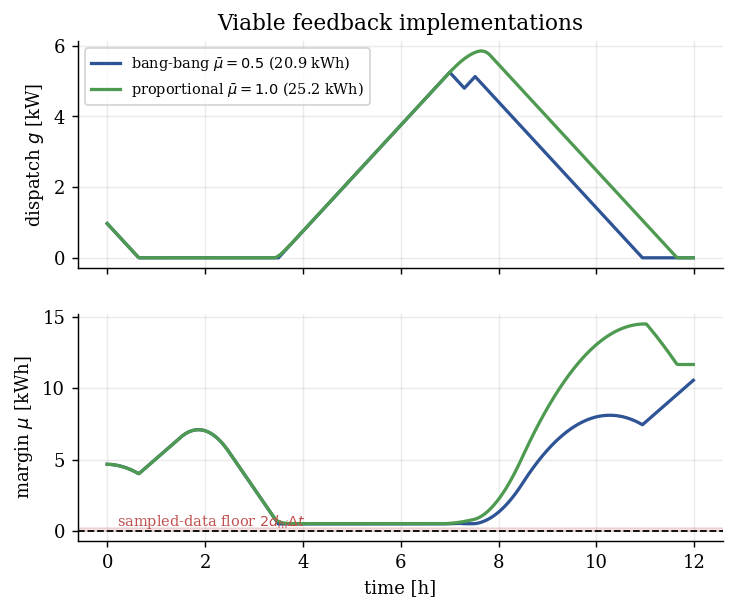

affine cost: bang-bang 27.73  proportional 32.50   (starts 1 vs 1)


In [12]:
fig, axs = plt.subplots(2, 1, figsize=(6.4, 5.0), sharex=True)
rb, rp = runs["Viable bang-bang"], runs["Viable proportional"]
axs[0].plot(t_wc, rb["g"], color=C["viable"], lw=1.8,
            label=fr"bang-bang $\bar\mu={CFG.mu_bar_bb}$ ({rb['fuel']:.1f} kWh)")
axs[0].plot(t_wc, rp["g"], color=C["prop"], lw=1.8,
            label=fr"proportional $\bar\mu={CFG.mu_bar_prop}$ ({rp['fuel']:.1f} kWh)")
axs[0].set_ylabel("dispatch $g$ [kW]"); axs[0].legend(fontsize=8)
axs[0].set_title("Viable feedback implementations")
axs[1].plot(t_wc, rb["mu"], color=C["viable"], lw=1.8)
axs[1].plot(t_wc, rp["mu"], color=C["prop"], lw=1.8)
axs[1].axhline(0, color="k", lw=1.0, ls="--")
axs[1].axhspan(0, 2 * P.d_hi * P.dt, color=C["greedy"], alpha=0.15)
axs[1].text(0.2, 2 * P.d_hi * P.dt + 0.15, r"sampled-data floor $2d_{hi}\Delta t$",
            fontsize=8, color=C["greedy"])
axs[1].set_ylabel(r"margin $\mu$ [kWh]"); axs[1].set_xlabel("time [h]")
fig.savefig(f"{FIGDIR}/fig_policy.pdf"); plt.show()
print(f"affine cost: bang-bang {affine_cost(rb):.2f}  proportional {affine_cost(rp):.2f}"
      f"   (starts {rb['starts']} vs {rp['starts']})")

## E2′ — Protection–efficiency trade-off (C10)

**Renamed.** The sweep of $\bar\mu$ is *not* a viable Pareto frontier: settings with
$\bar\mu<0$ deliberately admit negative margins and shed, so they are not viable
policies at all, and no nondominance has been established. Within the certified
subset $\bar\mu\ge2d_{hi}\Delta t$ (Prop. 2) unserved energy is identically zero, so
the meaningful trade-off there is **dispatchable energy against interior margin** —
i.e. against model-error tolerance — not against shedding.

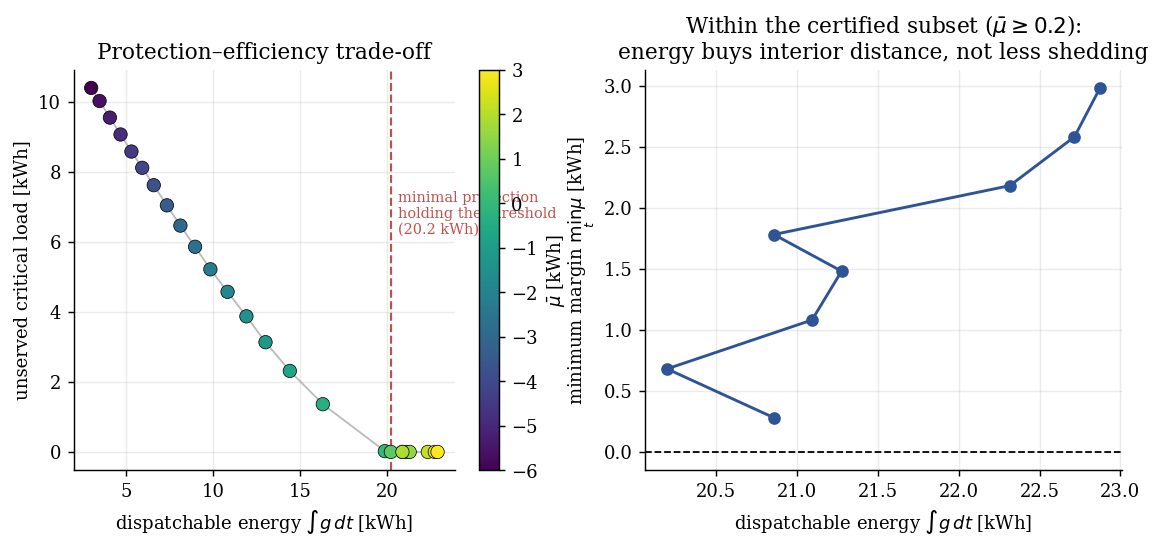

threshold held for all mu_bar >= 0.38 kWh; certified subset starts at 0.20 kWh


In [13]:
mu_sweep = np.linspace(-6.0, 3.0, 25)
sw = pd.DataFrame([dict(mu_bar=m, **{k: v for k, v in
                                     simulate(viable_bangbang(m), d_wc, P, record=True).items()
                                     if np.isscalar(v)}) for m in mu_sweep])
sw.to_csv(f"{RESDIR}/table_tradeoff.csv", index=False)
mu_cert = 2 * P.d_hi * P.dt

fig, axs = plt.subplots(1, 2, figsize=(10.4, 4.0))
sc = axs[0].scatter(sw["fuel"], sw["shed"], c=sw["mu_bar"], cmap="viridis", s=55,
                    zorder=3, edgecolor="k", lw=0.4)
axs[0].plot(sw["fuel"], sw["shed"], color="#BBBBBB", lw=1.0, zorder=1)
fig.colorbar(sc, ax=axs[0], label=r"$\bar\mu$ [kWh]")
knee = sw[sw["shed"] <= TOL]["fuel"].min()
axs[0].axvline(knee, color=C["greedy"], ls="--", lw=1.2)
axs[0].text(knee + 0.4, sw["shed"].max() * 0.6, f"minimal protection\nholding the threshold\n({knee:.1f} kWh)",
            fontsize=8, color=C["greedy"])
axs[0].set_xlabel(r"dispatchable energy $\int g\,dt$ [kWh]")
axs[0].set_ylabel("unserved critical load [kWh]")
axs[0].set_title("Protection–efficiency trade-off")

cert = sw[sw["mu_bar"] >= mu_cert]
axs[1].plot(cert["fuel"], cert["min_mu"], "o-", color=C["viable"], lw=1.6)
axs[1].axhline(0, color="k", ls="--", lw=1.0)
axs[1].set_xlabel(r"dispatchable energy $\int g\,dt$ [kWh]")
axs[1].set_ylabel(r"minimum margin $\min_t\mu$ [kWh]")
axs[1].set_title(f"Within the certified subset ($\\bar\\mu\\geq{mu_cert:.1f}$):\n"
                 "energy buys interior distance, not less shedding")
fig.savefig(f"{FIGDIR}/fig_frontier.pdf"); plt.show()
print(f"threshold held for all mu_bar >= {sw[sw['shed']<=TOL]['mu_bar'].min():.2f} kWh; "
      f"certified subset starts at {mu_cert:.2f} kWh")

## E3 — Stochastic drift (authoritative Monte-Carlo)

**C1:** this generator is now the authoritative experiment. Every parameter is in
`Cfg` and stated in the paper, so the ensemble is regenerable and checkable. The
previously published statistics came from a generator whose parameters were never
recorded and are withdrawn.

**C2:** the interval is the exact one-sided Clopper–Pearson upper limit for $0/n$
successes, $1-\alpha^{1/n}$ with $\alpha=0.05$, computed once and reused everywhere.

              policy  P(shed>0)  CP 95% upper  mean shed  median shed  P95 shed  mean energy  P95 energy  min margin
   Efficiency-greedy      1.000         1.000     38.184       37.278    57.309        0.323       0.323      -8.333
Fixed reserve 10 kWh      0.000         0.010      0.000        0.000     0.000       54.627      75.244       1.567
    Viable bang-bang      0.000         0.010      0.000        0.000     0.000       45.809      64.555       0.312
 Viable proportional      0.000         0.010      0.000        0.000     0.000       46.614      65.751       0.500

0/300 -> exact one-sided 95% upper bound 0.0099


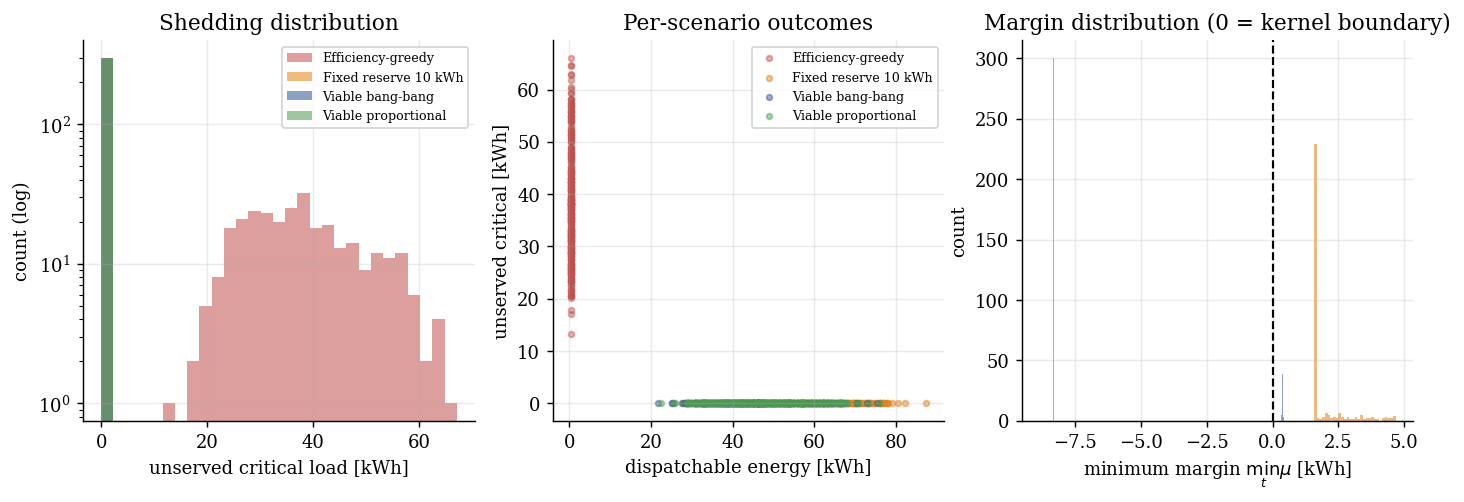

In [14]:
def cp_upper(k, n, alpha=0.05):
    """Exact one-sided Clopper-Pearson upper confidence limit."""
    return 1.0 if k == n else beta_dist.ppf(1 - alpha, k + 1, n - k)


rng = np.random.default_rng(CFG.seed)
scenarios = [ou_series(rng, P) for _ in range(CFG.n_mc)]

mc_pol = {"Efficiency-greedy": greedy,
          "Fixed reserve 10 kWh": fixed_reserve(10.0),
          "Viable bang-bang": viable_bangbang(CFG.mu_bar_bb),
          "Viable proportional": viable_proportional(CFG.mu_bar_prop)}
mc = {n: [simulate(pol, d, P, record=True) for d in scenarios] for n, pol in mc_pol.items()}

mc_tab = pd.DataFrame([{
    "policy": n,
    "P(shed>0)": np.mean([r["shed"] > TOL for r in rs]),
    "CP 95% upper": cp_upper(sum(r["shed"] > TOL for r in rs), CFG.n_mc),
    "mean shed": np.mean([r["shed"] for r in rs]),
    "median shed": np.median([r["shed"] for r in rs]),
    "P95 shed": np.percentile([r["shed"] for r in rs], 95),
    "mean energy": np.mean([r["fuel"] for r in rs]),
    "P95 energy": np.percentile([r["fuel"] for r in rs], 95),
    "min margin": np.min([r["min_mu"] for r in rs]),
} for n, rs in mc.items()])
mc_tab.to_csv(f"{RESDIR}/table_monte_carlo.csv", index=False)
print(mc_tab.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
CP0 = cp_upper(0, CFG.n_mc)
print(f"\n0/{CFG.n_mc} -> exact one-sided 95% upper bound {CP0:.4f}")

fig, axs = plt.subplots(1, 3, figsize=(13.2, 3.8))
cols = [C["greedy"], C["reserve"], C["viable"], C["prop"]]
bins = np.linspace(0, max(r["shed"] for rs in mc.values() for r in rs) + 1, 30)
for n, col in zip(mc, cols):
    axs[0].hist([r["shed"] for r in mc[n]], bins=bins, alpha=0.55, label=n, color=col)
axs[0].set_yscale("log"); axs[0].set_xlabel("unserved critical load [kWh]")
axs[0].set_ylabel("count (log)"); axs[0].legend(fontsize=7)
axs[0].set_title("Shedding distribution")
for n, col in zip(mc, cols):
    axs[1].scatter([r["fuel"] for r in mc[n]], [r["shed"] for r in mc[n]],
                   s=10, alpha=0.45, label=n, color=col)
axs[1].set_xlabel("dispatchable energy [kWh]"); axs[1].set_ylabel("unserved critical [kWh]")
axs[1].legend(fontsize=7); axs[1].set_title("Per-scenario outcomes")
for n, col in zip(mc, cols):
    axs[2].hist([r["min_mu"] for r in mc[n]], bins=30, alpha=0.55, color=col, label=n)
axs[2].axvline(0, color="k", ls="--", lw=1.2)
axs[2].set_xlabel(r"minimum margin $\min_t \mu$ [kWh]"); axs[2].set_ylabel("count")
axs[2].set_title("Margin distribution (0 = kernel boundary)")
fig.savefig(f"{FIGDIR}/fig_mc.pdf"); plt.show()

## E4 — Predictive control (B1, B2)

A genuine finite-horizon economic MPC, optimised over a **sequence** of ramp
decisions by dynamic programming, in three configurations: plain, with the
closed-form kernel as a **terminal viability constraint**, and under forecast bias.

In [15]:
bench = [("Efficiency-greedy", lambda: simulate(greedy, d_wc, P), "none"),
         ("Fixed reserve 4 kWh", lambda: simulate(fixed_reserve(4.0), d_wc, P), "none"),
         ("Fixed reserve 8 kWh", lambda: simulate(fixed_reserve(8.0), d_wc, P), "none"),
         ("Fixed reserve 10 kWh", lambda: simulate(fixed_reserve(10.0), d_wc, P), "none")]
for H in (0.5, 1.0, 2.0, 4.0, 6.0):
    bench.append((f"MPC H={H} h", lambda H=H: run_mpc(mpc_policy(H), d_wc, P), f"{H} h"))
    bench.append((f"MPC H={H} h + terminal viability",
                  lambda H=H: run_mpc(mpc_policy(H, terminal_viability=True), d_wc, P), f"{H} h"))
for fb in (0.10, 0.20, 0.30):
    bench.append((f"MPC H=4 h, {fb:.0%} under-forecast",
                  lambda fb=fb: run_mpc(mpc_policy(4.0, forecast_bias=fb), d_wc, P), "4 h"))
    bench.append((f"MPC H=4 h + terminal viability, {fb:.0%} under-forecast",
                  lambda fb=fb: run_mpc(mpc_policy(4.0, forecast_bias=fb,
                                                   terminal_viability=True), d_wc, P), "4 h"))
bench += [("Viable bang-bang", lambda: simulate(viable_bangbang(CFG.mu_bar_bb), d_wc, P), "none"),
          ("Viable proportional", lambda: simulate(viable_proportional(CFG.mu_bar_prop), d_wc, P), "none")]

e4 = pd.DataFrame([{"policy": n, "energy (kWh)": r["fuel"], "shed (kWh)": r["shed"],
                    "starts": r["starts"], "forecast": f}
                   for n, fn, f in bench for r in [fn()]])
e4.to_csv(f"{RESDIR}/table_baselines.csv", index=False)
print(e4.to_string(index=False, float_format=lambda v: f"{v:7.2f}"))

                                            policy  energy (kWh)  shed (kWh)  starts forecast
                                 Efficiency-greedy          0.32       12.70       0     none
                               Fixed reserve 4 kWh         23.93        4.35       1     none
                               Fixed reserve 8 kWh         30.65        0.42       1     none
                              Fixed reserve 10 kWh         33.09        0.00       1     none
                                       MPC H=0.5 h         13.82        6.49       1    0.5 h
                  MPC H=0.5 h + terminal viability         20.76        0.00       1    0.5 h
                                       MPC H=1.0 h         18.70        4.35       1    1.0 h
                  MPC H=1.0 h + terminal viability         18.51        0.00       1    1.0 h
                                       MPC H=2.0 h         18.70        0.00       1    2.0 h
                  MPC H=2.0 h + terminal viability         1

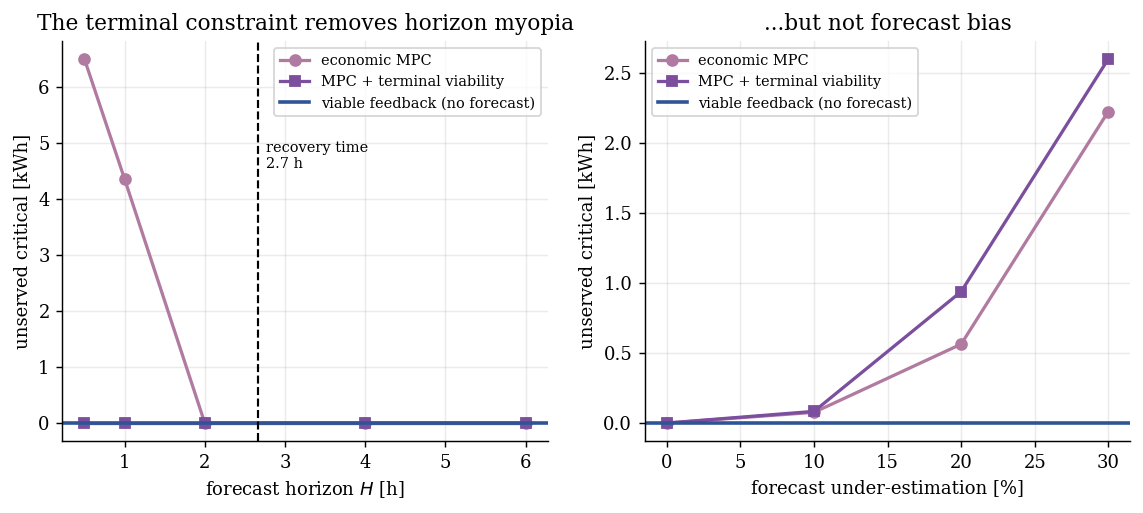

In [16]:
Hs = [0.5, 1.0, 2.0, 4.0, 6.0]
plain = [e4.loc[e4.policy == f"MPC H={H} h", "shed (kWh)"].item() for H in Hs]
withV = [e4.loc[e4.policy == f"MPC H={H} h + terminal viability", "shed (kWh)"].item() for H in Hs]
fb_l = [0.0, 0.10, 0.20, 0.30]
bias_plain = [e4.loc[e4.policy == "MPC H=4.0 h", "shed (kWh)"].item()] + \
             [e4.loc[e4.policy == f"MPC H=4 h, {f:.0%} under-forecast", "shed (kWh)"].item() for f in fb_l[1:]]
bias_V = [e4.loc[e4.policy == "MPC H=4.0 h + terminal viability", "shed (kWh)"].item()] + \
         [e4.loc[e4.policy == f"MPC H=4 h + terminal viability, {f:.0%} under-forecast", "shed (kWh)"].item()
          for f in fb_l[1:]]

fig, axs = plt.subplots(1, 2, figsize=(10.6, 4.0))
axs[0].plot(Hs, plain, "o-", color=C["mpc"], lw=1.8, label="economic MPC")
axs[0].plot(Hs, withV, "s-", color=C["mpcv"], lw=1.8, label="MPC + terminal viability")
axs[0].axhline(0, color=C["viable"], lw=2.0, label="viable feedback (no forecast)")
trec = (P.d_hi - CFG.g0) / P.R
axs[0].axvline(trec, color="k", ls="--", lw=1.2)
axs[0].text(trec + 0.1, max(plain) * 0.7, f"recovery time\n{trec:.1f} h", fontsize=8)
axs[0].set_xlabel("forecast horizon $H$ [h]"); axs[0].set_ylabel("unserved critical [kWh]")
axs[0].set_title("The terminal constraint removes horizon myopia")
axs[0].legend(fontsize=8)

axs[1].plot([f*100 for f in fb_l], bias_plain, "o-", color=C["mpc"], lw=1.8, label="economic MPC")
axs[1].plot([f*100 for f in fb_l], bias_V, "s-", color=C["mpcv"], lw=1.8, label="MPC + terminal viability")
axs[1].axhline(0, color=C["viable"], lw=2.0, label="viable feedback (no forecast)")
axs[1].set_xlabel("forecast under-estimation [%]"); axs[1].set_ylabel("unserved critical [kWh]")
axs[1].set_title("...but not forecast bias")
axs[1].legend(fontsize=8)
fig.savefig(f"{FIGDIR}/fig_baselines.pdf"); plt.show()

**Reading.** The terminal viability constraint does exactly one thing, and does it
cleanly: it removes *horizon myopia*. At $H=0.5$ h the plain controller sheds while
the constrained one sheds nothing, and at $H=1$ h it does so at slightly **lower**
energy — the constraint is not merely a safety tax, it also stops the controller
from digging a hole it must expensively climb out of.

It does **not** repair a biased forecast. Under a $20$–$30\%$ under-forecast both
predictive controllers shed, because the constraint binds only at the horizon end
and is evaluated against a deficit the controller already believes to be small,
whereas the depletion happens earlier. Only the forecast-free viable feedback holds
the threshold in both experiments. This is a sharper conclusion than "MPC needs a
long horizon": *prediction and certification fail in different ways, and the kernel
is the cheaper insurance against the failure that prediction cannot see.*

## E5 — Model uncertainty

The guarantee is exact **given the parameters**. Here the plant's worst deficit,
ramp rate, or sampling period differs from what the policy assumes.

In [17]:
e5_rows = []
for lab, p_true, p_design in [
    ("true $d_{hi}=6$, nominal kernel", replace(P, d_hi=6.0), P),
    ("true $d_{hi}=6$, inflated kernel $\\epsilon_d=1$", replace(P, d_hi=6.0), replace(P, d_hi=6.0)),
    ("true $R=1.2$, nominal kernel", replace(P, R=1.2), P),
    ("true $R=1.2$, derated kernel $\\epsilon_R=0.3$", replace(P, R=1.2), replace(P, R=1.2)),
    ("$\\Delta t=0.2$ h, $\\bar\\mu=0.5<2d_{hi}\\Delta t$", replace(P, dt=0.2), replace(P, dt=0.2)),
]:
    _, d_true = worst_case_series(p_true)
    for pol_name, mk in (("bang-bang", lambda: viable_bangbang(CFG.mu_bar_bb)),
                         ("proportional", lambda: viable_proportional(CFG.mu_bar_prop))):
        pol = mk()
        r = simulate(lambda s, g, d, k, ds, _p: pol(s, g, d, k, ds, p_design), d_true, p_true)
        e5_rows.append({"case": lab, "policy": pol_name,
                        "energy (kWh)": r["fuel"], "shed (kWh)": r["shed"]})
e5 = pd.DataFrame(e5_rows)
e5.to_csv(f"{RESDIR}/table_robustness.csv", index=False)
print(e5.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nrequired reserve at g=0: assumed {s_min(0.0, P):.2f} kWh, "
      f"actual at d_hi=6 {s_min(0.0, replace(P, d_hi=6.0)):.2f} kWh")

                                           case       policy  energy (kWh)  shed (kWh)
                true $d_{hi}=6$, nominal kernel    bang-bang         27.80        3.26
                true $d_{hi}=6$, nominal kernel proportional         29.10        3.07
true $d_{hi}=6$, inflated kernel $\epsilon_d=1$    bang-bang         29.97        0.00
true $d_{hi}=6$, inflated kernel $\epsilon_d=1$ proportional         31.96        0.00
                   true $R=1.2$, nominal kernel    bang-bang         22.98        1.60
                   true $R=1.2$, nominal kernel proportional         24.63        1.39
  true $R=1.2$, derated kernel $\epsilon_R=0.3$    bang-bang         23.22        0.00
  true $R=1.2$, derated kernel $\epsilon_R=0.3$ proportional         26.31        0.00
$\Delta t=0.2$ h, $\bar\mu=0.5<2d_{hi}\Delta t$    bang-bang         25.44        0.19
$\Delta t=0.2$ h, $\bar\mu=0.5<2d_{hi}\Delta t$ proportional         26.04        0.00

required reserve at g=0: assumed 8.33 kWh,

## E6 — Refined physical plant, full dispatch (M6)

The refinements of Prop. 3 are propagated through a **complete dispatch experiment**,
not shown only as a shifted boundary: discharge efficiency, a depth-of-discharge
floor, and generator start-up dead time act together, and the policies use the
correspondingly refined kernel.

In [18]:
P_ref = replace(P, eta=0.92, s_dod=2.0, tau=1/6)
_, d_ref = worst_case_series(P_ref)
e6 = pd.DataFrame([{
    "policy": n, "energy (kWh)": r["fuel"], "shed (kWh)": r["shed"],
    "starts": r["starts"], "affine cost": affine_cost(r), "min margin": r["min_mu"]}
    for n, pol in (("Efficiency-greedy", greedy),
                   ("Fixed reserve 10 kWh", fixed_reserve(10.0)),
                   ("Viable bang-bang (refined kernel)", viable_bangbang(CFG.mu_bar_bb)),
                   ("Viable proportional (refined kernel)", viable_proportional(CFG.mu_bar_prop)))
    for r in [simulate(pol, d_ref, P_ref, record=True)]])
e6.to_csv(f"{RESDIR}/table_refined_plant.csv", index=False)
print(f"refined plant: eta={P_ref.eta}, s_dod={P_ref.s_dod} kWh, tau={P_ref.tau*60:.0f} min")
print(f"s_min(0): nominal {s_min(0.0,P):.2f} -> refined {s_min(0.0,P_ref):.2f} kWh; "
      f"viable fraction {viable_fraction(P):.3f} -> {viable_fraction(P_ref):.3f}")
print(e6.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

refined plant: eta=0.92, s_dod=2.0 kWh, tau=10 min
s_min(0): nominal 8.33 -> refined 11.96 kWh; viable fraction 0.884 -> 0.755
                              policy  energy (kWh)  shed (kWh)  starts  affine cost  min margin
                   Efficiency-greedy          0.32       17.15       0         0.72       -9.96
                Fixed reserve 10 kWh         33.28        1.15       1        40.97       -2.05
   Viable bang-bang (refined kernel)         23.51        0.00       1        30.79        0.30
Viable proportional (refined kernel)         26.80        0.00       1        34.57        0.53


## A. Kernel variants (Proposition 3)

**C6 fixed:** each variant's viable fraction is now the integral of *its own*
boundary. The previous version printed the nominal closed form for all of them, so
every refinement wrongly showed 0.884.

**C7:** discharge efficiency enters as $\dot s=(g-d)/\eta$ while discharging (the
battery must supply $(d-g)/\eta$ to deliver $d-g$), which is what produces the
$1/\eta$ scaling of the drawdown integral. Charging is unaffected.

**C8:** curtailment is consistent because the deficit is now $d=L_c+L_{nc}-r$.

**C9:** the bounded-drought case is a **finite-horizon survival set**, not an
infinite-horizon kernel: it certifies survival of a single drought episode of length
at most $T_d$. Repeated droughts without sufficient recharge are outside the class,
and the label in the table says so.

                   variant  s_min(0) [kWh]  viable fraction  infinite-horizon kernel
                   nominal           8.333            0.884                     True
    $\eta=0.9$ (discharge)           9.259            0.871                     True
     DoD floor $s_{dod}=2$          10.333            0.784                     True
   dead time $\tau=10$ min           9.167            0.867                     True
      dead time $\tau=1$ h          13.333            0.780                     True
$T_d=2$ h (finite-horizon)           7.000            0.892                    False
 curtailable $L_{nc}=1$ kW           5.333            0.941                     True
        refined plant (E6)          11.964            0.755                     True


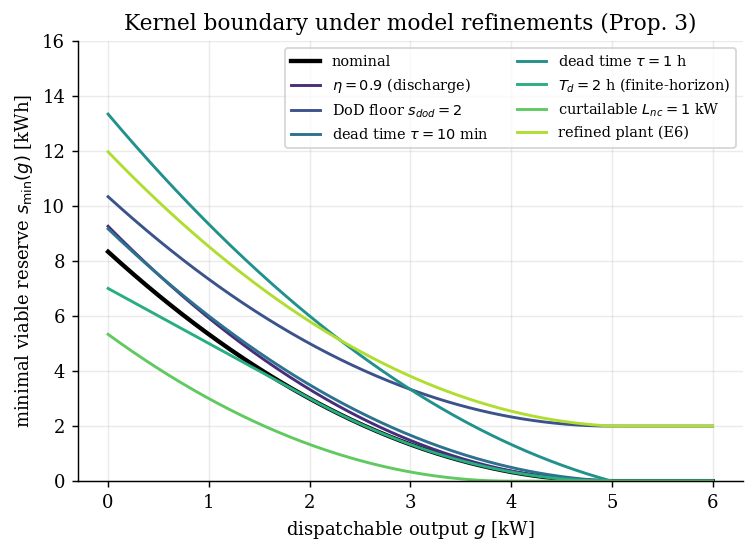

In [19]:
variants = {
    "nominal": P,
    r"$\eta=0.9$ (discharge)": replace(P, eta=0.9),
    r"DoD floor $s_{dod}=2$": replace(P, s_dod=2.0),
    r"dead time $\tau=10$ min": replace(P, tau=1/6),
    r"dead time $\tau=1$ h": replace(P, tau=1.0),
    r"$T_d=2$ h (finite-horizon)": replace(P, T_d=2.0),
    r"curtailable $L_{nc}=1$ kW": replace(P, L_nc=1.0),
    "refined plant (E6)": P_ref,
}
var_tab = pd.DataFrame([{
    "variant": n,
    "s_min(0) [kWh]": float(s_min(0.0, p_)),
    "viable fraction": viable_fraction(p_),
    "infinite-horizon kernel": np.isinf(p_.T_d),
} for n, p_ in variants.items()])
var_tab.to_csv(f"{RESDIR}/table_kernel_variants.csv", index=False)
print(var_tab.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
assert var_tab["viable fraction"].nunique() > 1, "C6 regression: variants must differ"

fig, ax = plt.subplots(figsize=(6.6, 4.4))
gg = np.linspace(0, P.G_max, 400)
for (n, p_), col in zip(variants.items(), plt.cm.viridis(np.linspace(0, .88, len(variants)))):
    ax.plot(gg, s_min(gg, p_), lw=2.4 if n == "nominal" else 1.6,
            color="k" if n == "nominal" else col, label=n)
ax.set_xlabel(r"dispatchable output $g$ [kW]")
ax.set_ylabel(r"minimal viable reserve $s_{\min}(g)$ [kWh]")
ax.set_title("Kernel boundary under model refinements (Prop. 3)")
ax.set_ylim(0, 16); ax.legend(fontsize=8, ncol=2)
fig.savefig(f"{FIGDIR}/fig_variants.pdf"); plt.show()

## B. Sampled-data protection margin (Proposition 2)

Under $u=+R$, $\dot\mu=d_{hi}-d\ge0$ **continuously**, so protection under
zero-order hold is exact. Under $u=-R$, $\dot\mu=2g-d-d_{hi}\ge-2d_{hi}$, so at most
$2d_{hi}\Delta t$ is lost within one step. Hence $\bar\mu\ge2d_{hi}\Delta t$ suffices.

**N7:** the sweep below also serves as the $\Delta t$ convergence test, separating
genuine policy behaviour from integration artefacts.

In [20]:
sd_rows = []
for dt_ in (0.02, 0.05, 0.1, 0.2, 0.4):
    p_ = replace(P, dt=dt_)
    _, d_ = worst_case_series(p_)
    bound = 2 * p_.d_hi * dt_
    for mb in sorted({0.0, bound / 2, bound, 1.5 * bound, CFG.mu_bar_bb}):
        r = simulate(viable_bangbang(mb), d_, p_, record=True)
        sd_rows.append(dict(dt=dt_, mu_bar=mb, bound=bound, energy=r["fuel"],
                            shed=r["shed"], min_mu=r["min_mu"], satisfies=mb >= bound - 1e-12))
sd = pd.DataFrame(sd_rows)
sd.to_csv(f"{RESDIR}/table_sampled_data.csv", index=False)
print(sd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
ok = sd[sd.satisfies]
assert (ok.min_mu >= -1e-9).all() and (ok.shed <= TOL).all(), "Prop. 2 violated"
print(f"\nall {len(ok)} runs satisfying mu_bar >= 2*d_hi*dt: margin never negative, "
      f"nothing shed.  Nominal bound = {2*P.d_hi*P.dt:.2f} kWh")

   dt  mu_bar  bound  energy  shed  min_mu  satisfies
0.020   0.000  0.200  19.854 0.022  -0.020      False
0.020   0.100  0.200  20.273 0.000   0.080      False
0.020   0.200  0.200  20.475 0.000   0.180       True
0.020   0.300  0.200  20.678 0.000   0.280       True
0.020   0.500  0.200  20.883 0.000   0.480       True
0.050   0.000  0.500  20.135 0.056  -0.050      False
0.050   0.250  0.500  19.749 0.000   0.200      False
0.050   0.500  0.500  19.749 0.000   0.450       True
0.050   0.750  0.500  20.218 0.000   0.700       True
0.100   0.000  1.000  19.605 0.117  -0.098      False
0.100   0.500  1.000  20.820 0.000   0.402      False
0.100   1.000  1.000  20.820 0.000   0.902       True
0.100   1.500  1.000  20.820 0.000   1.402       True
0.200   0.000  2.000  19.680 0.190  -0.193      False
0.200   0.500  2.000  25.440 0.190  -0.193      False
0.200   1.000  2.000  24.240 0.000   0.807      False
0.200   2.000  2.000  24.240 0.000   1.807       True
0.200   3.000  2.000  24.240

## C. Test suite (N4, N8)

Unit tests on the analytic kernel and regression assertions on the headline numbers.
The notebook **fails loudly** if any manuscript value drifts.

In [21]:
def test_kernel_boundary():
    """On the boundary, u=+R holds the margin; below it, the state is lost."""
    for g in (0.0, 1.0, 2.5, 4.0):
        s = s_min(g, P)
        ss, gg_, _, sh = step_state(s, g, +P.R, P.d_hi, P)
        assert margin(ss, gg_, P) >= -1e-9, f"boundary not held at g={g}"
        assert sh == 0.0
    s, g = s_min(1.0, P) - 0.5, 1.0
    r = simulate(viable_bangbang(0.0), np.full(600, P.d_hi), P, s0=s, g0=g)
    assert r["shed"] > 0, "a state below the boundary must eventually shed"


def test_above_dhi():
    """For g >= d_hi no reserve is required and the margin cannot fall under d_hi."""
    assert s_min(P.d_hi, P) == 0.0 and s_min(P.G_max, P) == 0.0
    ss, gg_, _, _ = step_state(0.0, P.d_hi, 0.0, P.d_hi, P)
    assert margin(ss, gg_, P) >= -1e-9


def test_saturation():
    """U(g) is one-sided at the generator bounds (C5)."""
    assert admissible_u(-P.R, 0.0, P) == 0.0
    assert admissible_u(+P.R, P.G_max, P) == 0.0
    _, g_lo, _, _ = step_state(5.0, 0.0, -P.R, 0.0, P)
    _, g_hi, _, _ = step_state(5.0, P.G_max, +P.R, 0.0, P)
    assert g_lo == 0.0 and g_hi == P.G_max


def test_zoh_exact():
    """step_state reproduces the exact solution of the LTI dynamics over one step."""
    s, g, u, d = 10.0, 1.0, 0.7, 2.0
    s_ex = s + (g - d) * P.dt + 0.5 * u * P.dt**2
    ss, gg_, _, _ = step_state(s, g, u, d, P)
    assert abs(ss - s_ex) < 1e-12 and abs(gg_ - (g + u * P.dt)) < 1e-12


def test_empty_kernel():
    """G_max < d_hi leaves nothing defensible."""
    p_bad = replace(P, G_max=4.0, d_hi=5.0)
    assert s_min(p_bad.G_max, p_bad) > 0


def test_efficiency_scaling():
    """Prop. 3a: the boundary scales as 1/eta."""
    p_e = replace(P, eta=0.5)
    assert abs(s_min(0.0, p_e) - 2 * s_min(0.0, P)) < 1e-9


for fn in (test_kernel_boundary, test_above_dhi, test_saturation, test_zoh_exact,
           test_empty_kernel, test_efficiency_scaling):
    fn(); print(f"PASS  {fn.__name__}")

# regression assertions on headline values
assert abs(frac - 0.884259259) < 1e-6
assert abs(s_min(0.0, P) - 25/3) < 1e-9
assert runs["Viable bang-bang"]["shed"] <= TOL
assert runs["Viable proportional"]["shed"] <= TOL
assert runs["Efficiency-greedy"]["shed"] > 10
assert mc_tab.loc[mc_tab.policy.str.startswith("Viable"), "P(shed>0)"].max() == 0.0
print("PASS  headline regressions")

PASS  test_kernel_boundary
PASS  test_above_dhi
PASS  test_saturation
PASS  test_zoh_exact
PASS  test_empty_kernel
PASS  test_efficiency_scaling
PASS  headline regressions


## D. Reproducibility summary

**N10:** this block is generated from the objects above, so it cannot drift from the
experiments. Every number quoted in the manuscript appears here.

In [22]:
summary = f"""
CONFIGURATION      seed={CFG.seed}  dt={P.dt} h  S_max={P.S_max} kWh  G_max={P.G_max} kW
                   R={P.R} kW/h  d_hi={P.d_hi} kW  d_lo={P.d_lo} kW
OU disturbance     theta={CFG.ou_theta}  sigma={CFG.ou_sigma}  mean={CFG.ou_mean_offset}
                   +{CFG.ou_mean_amp}*sin(2pi t/{CFG.ou_period})  plateaus={CFG.n_plateau}
                   of {CFG.plateau_dur} h at d_hi;  n={CFG.n_mc}, T={CFG.T_mc} h

KERNEL
  viable fraction (integral / closed form) {frac:.4f} / {frac_cf:.4f}
  closed-form validity  R >= {P.d_hi**2/(2*P.S_max):.3f} kW/h            [R = {P.R}]
  s_min(0)                                 {s_min(0.0,P):.3f} kWh
  grid check ({Ns0}x{Ng0}, h={h0})          {V0.mean():.3f}
  sampled-data margin 2*d_hi*dt            {2*P.d_hi*P.dt:.2f} kWh   [used {CFG.mu_bar_bb}]

WORST-CASE DROUGHT ({CFG.T_wc:.0f} h)
{e2.to_string(index=False, float_format=lambda v: f'{v:.2f}')}

PREDICTIVE CONTROL (worst case)
{e4[e4.policy.str.contains('MPC')].to_string(index=False, float_format=lambda v: f'{v:.2f}')}

MONTE CARLO (n={CFG.n_mc}, {CFG.T_mc:.0f} h)
{mc_tab.to_string(index=False, float_format=lambda v: f'{v:.3f}')}
  exact one-sided 95% upper bound for 0/{CFG.n_mc}: {CP0:.4f}

MODEL UNCERTAINTY
{e5.to_string(index=False, float_format=lambda v: f'{v:.2f}')}

REFINED PLANT (eta={P_ref.eta}, s_dod={P_ref.s_dod}, tau={P_ref.tau*60:.0f} min)
{e6.to_string(index=False, float_format=lambda v: f'{v:.2f}')}

KERNEL VARIANTS
{var_tab.to_string(index=False, float_format=lambda v: f'{v:.3f}')}
"""
print(summary)
with open(f"{RESDIR}/reproducibility_summary.txt", "w") as f:
    f.write(summary)
print("figures ->", sorted(os.listdir(FIGDIR)))
print("results ->", sorted(os.listdir(RESDIR)))


CONFIGURATION      seed=20250901  dt=0.02 h  S_max=20.0 kWh  G_max=6.0 kW
                   R=1.5 kW/h  d_hi=5.0 kW  d_lo=-3.0 kW
OU disturbance     theta=1.2  sigma=1.1  mean=1.0
                   +1.5*sin(2pi t/24.0)  plateaus=(1, 2)
                   of (2.0, 6.0) h at d_hi;  n=300, T=24.0 h

KERNEL
  viable fraction (integral / closed form) 0.8843 / 0.8843
  closed-form validity  R >= 0.625 kW/h            [R = 1.5]
  s_min(0)                                 8.333 kWh
  grid check (161x121, h=0.06)          0.890
  sampled-data margin 2*d_hi*dt            0.20 kWh   [used 0.5]

WORST-CASE DROUGHT (12 h)
              policy  dispatchable energy (kWh)  unserved critical (kWh)  starts  min margin (kWh)  affine cost
   Efficiency-greedy                       0.32                    12.70       0             -8.33         0.72
Fixed reserve 10 kWh                      33.09                     0.00       1              1.62        40.73
    Viable bang-bang                      20.